# Astro 461 Python and Unix for Astronomy: A review of the basics

Welcome to the Astro 461 Python tutorial. In this session, we will cover key Python and Unix concepts that are useful for your astronomy coursework and research. This notebook assumes you have some basic familiarity with Python and Jupyter notebooks.

## Table of Contents

1. Data Structures
2. Working with Data
3. Data Analysis: Fundamental Techniques
4. Data Visualization with Matplotlib
5. Basic Unix

---
---

Note: Practice problems are denoted with <span style="color:darkcyan"> cyan text.</span>

## 1. Data Structures

Python has several built-in data structures, which are great for manipulating data. Let's review lists, tuples, dictionaries, and sets.


### Lists
Lists are ordered, mutable (can be modified) collections of items. List can be homogenous, meaning all elements have the same datatype, or heterogeneous, containing multiple data types and even multiple shapes. It is an ordered collection supporting negative indexing. A list can be created using [] containing data values. Contents of lists can be easily merged and copied using Python's inbuilt functions. 

In [1]:
planets = ['Mercury', 'Venus', 'Earth', 'Mars', 'Jupiter'] # A homogeneous list of strings
print('Planets:', planets)

# Accessing list elements
print('First planet:', planets[0])

# Appending a new element
planets.append('Saturn')
print('Updated list:', planets)

random = [int(1), 2.5, 'Hello', True, ['a', 4.2e3]] # A heterogeneous list
print('Random list:', random)

for i in random: # We will talk about loops and print statements later
    print(f'Data type of element {i}: {type(i)}')

Planets: ['Mercury', 'Venus', 'Earth', 'Mars', 'Jupiter']
First planet: Mercury
Updated list: ['Mercury', 'Venus', 'Earth', 'Mars', 'Jupiter', 'Saturn']
Random list: [1, 2.5, 'Hello', True, ['a', 4200.0]]
Data type of element 1: <class 'int'>
Data type of element 2.5: <class 'float'>
Data type of element Hello: <class 'str'>
Data type of element True: <class 'bool'>
Data type of element ['a', 4200.0]: <class 'list'>


### Tuples

A Tuple is a collection of Python objects separated by commas. In some ways, a tuple is similar to a list in terms of indexing, nested objects, and repetition but a tuple is immutable (elements CANNOT be changed, added, or removed), unlike lists that are mutable (elements CAN be changed, added, or removed). Because they are immutable, tuples are generally faster than lists when you need to iterate over them or store a static collection of items. Like lists, tuples can be heterogenous.

In [2]:
# Example of a tuple
planet_tuple = ('Mercury', 'Venus', 'Earth', 'Mars', 'Jupiter')

# Accessing elements
print("First planet:", planet_tuple[0])

# Trying to modify an element raises an error
# planet_tuple[0] = 'Mercury2'  # Uncommenting this line will raise a TypeError

# But trying to modify a list element works
# planets[0] = 'Mercury2' # Uncommenting this line will change the first element of the list
# print('Updated list:', planets)

First planet: Mercury


### Arrays

An array is a vector containing homogeneous elements. Arrays store their elements in contiguous memory locations, meaning each element is directly next to the previous one in memory. Typically, the size of an array is fixed when it is created. Therefore, inserting or deleting elements into an array can be costly in terms of performance, especially if the operation requires shifting many elements to accommodate the change. However, accessing an element by its index (known as indexing) is very fast, as the memory location of each element can be directly calculated due to the contiguous arrangement of elements.

In [3]:
import numpy as np # An important library for numerical operations

# Create a numpy array for distance from the sun (in AU)
distances = np.array([0.39, 0.72, 1.00, 1.52, 5.20])

# Basic array operations
print('Mean distance:', np.mean(distances))
print('Maximum distance:', np.max(distances))

# Arrats are mutable, but can be computationally costly if they are large and you need to shift many elements
distances[0] = 0.4 # This changes the first element of the array
distances = np.append(distances, 9.58) # This adds a new element to the end of the array
print('Updated distances:', distances)

Mean distance: 1.766
Maximum distance: 5.2
Updated distances: [0.4  0.72 1.   1.52 5.2  9.58]


### Dictionaries
A Python dictionary is a data structure that stores the value in key: value pairs. Values in a dictionary can be of any data type and can be duplicated, whereas keys can't be repeated and must be immutable (can't be modified). They are ideal for fast lookups and representing structured data, counting the frequency (number of occurances) of elements in a list, string, or any iterable, fast lookup tables (O(1) average time complexity), and storing and accessing JSON data (which can be useful for setting defaults in interactive scripts, for example). 

In [4]:
planet_distances = {    # Dictinoaries use the {} braces instead of [] like lists
    'Mercury': 57.9,    # Distance in millions of km
    'Venus': 108.2,
    'Earth': 149.6,
    'Mars': 227.9
}

# Accessing a value
print('Distance to Mars:', planet_distances['Mars']) # Notice how we access a value in a dictionary!

# Adding a new key-value pair
planet_distances['Jupiter'] = 778.5
print('Updated dictionary:', planet_distances)

Distance to Mars: 227.9
Updated dictionary: {'Mercury': 57.9, 'Venus': 108.2, 'Earth': 149.6, 'Mars': 227.9, 'Jupiter': 778.5}


### Sets
A set is an unordered collection of multiple items that can have different datatypes. In Python, sets are mutable, unindexed and do not contain duplicates. The order of elements in a set is not preserved and can change.

In [5]:
observed_galaxies = {'Milky Way', 'Andromeda', 'Triangulum'}
print('Observed Galaxies:', observed_galaxies)

# Adding a new element
observed_galaxies.add('Sombrero')
print('Updated set:', observed_galaxies)

# You can also use the set() function to create a set from a list
galaxy_list = ['Milky Way', 'Andromeda', 'Triangulum', 'Sombrero']
observed_galaxies = set(galaxy_list)
print('Set from list:', observed_galaxies)
print('')

# Unindexed: Accessing elements by index is not possible
try:
    print(observed_galaxies[0])
except TypeError as e:
    print(e)

Observed Galaxies: {'Andromeda', 'Triangulum', 'Milky Way'}
Updated set: {'Andromeda', 'Triangulum', 'Sombrero', 'Milky Way'}
Set from list: {'Andromeda', 'Triangulum', 'Sombrero', 'Milky Way'}

'set' object is not subscriptable


### <span style="color:darkcyan"> Practice Problem 1:</span> Lists and Planetary Distances
Create a list named exoplanets with the following exoplanet names: 'Kepler-452b', 'GJ 1214 b', and 'HD 209458 b'. Assume their approximate distances from Earth are 1402, 42, and 154 light years, respectively. Add these distances to a second list. Finally, calculate and print the average distance of these exoplanets from Earth.

### <span style="color:darkcyan"> Practice Problem 2:</span> Tuples and Gravitational Binding Energy
Consider a tuple named planetary_bodies containing the radii of three planets: (1.0, 3.5, 4.2) in Earth radii. Write a function that calculates the gravitational binding energy for a planet in terms of Earth's binding energy. Assume the mass scales with the cube of the radius. Use this function to print the binding energy of each planet in this tuple.

### <span style="color:darkcyan"> Practice Problem 3:</span> Dictionaries and Number of Moons
Create a dictionary where the planets 'Jupiter', 'Saturn', and 'Neptune' are keys, and their respective number of natural moons are values. Update the dictionary with 'Uranus' and its moons. Write code to determine which planet in the dictionary has the most moons and print the number.

---

## 2. Working with Data

This section introduces the foundational skills you need to begin interfacing with data in Python. Here we'll use two very useful libraries: Pandas and Astropy. We will cover the basics of reading and handling data stored in common formats such as CSV (Comma-Separated Values), TSV (Tab-Separated Values), and ASCII files.

You'll learn how to use Pandas to load datasets into DataFrame structures, a versatile tool for organizing and analyzing tabular data. We will explore simple techniques for reading data files, accessing specific data columns or rows, and performing basic manipulations to prepare your data for analysis.

In addition to Pandas, we'll utilize Astropy, which is optimized to interface with astronomical data. A particularly useful aspect of Astropy is its ability to incorporate units, coordinates, and much more!

Let's first look at some sample data to see how it is structured.

In [6]:
# Define the path to the data
data_path = "./Sampledata/python_unix_review/data/"

# Preview the file header to understand the data structure and comments
with open(data_path + "sample_stars.csv", "r") as f:
    for i in range(5):
        print(f.readline().strip())

# Name, RA[unit=deg], DEC[unit=deg], Mag[unit=], Distance[unit=pc], Temperature[unit=K], Radius[unit=R_sun]
Name,RA,DEC,Mag,Distance,Temperature,Radius
Vega,279.2347,38.7837,0.58,7.7,9602,2.8
Sirius,101.2875,-16.7161,1.42,2.64,9940,1.7
Canopus,95.9879,-52.6957,-5.53,94.4,7350,71


### Pandas
Pandas is an excellent tool for handling tabular data. It allows you to efficiently organize, manipulate, and analyze datasets.

In [7]:
import pandas as pd # A powerful library for data manipulation and analysis

# Load CSV data into a DataFrame. Skip comments by specifying the comment character.
df = pd.read_csv(data_path + "sample_stars.csv", comment='#')
print("\nDataFrame loaded from CSV:")
print(df.head(3))  


DataFrame loaded from CSV:
      Name        RA      DEC   Mag  Distance  Temperature  Radius
0     Vega  279.2347  38.7837  0.58      7.70         9602     2.8
1   Sirius  101.2875 -16.7161  1.42      2.64         9940     1.7
2  Canopus   95.9879 -52.6957 -5.53     94.40         7350    71.0


We can access specific indices of data in Pandas DataFrames using ```df.iloc[i]``` and we can look at different columns by specifying their name in ```[]``` brackets.

In [8]:
# Accessing columns and rows
print("First three star names:", df["Name"].tolist()[0:3])  # Get first 3 star names
print("First star:", df.iloc[0]["Name"], "| Mag:", df.iloc[0]["Mag"], "| Distance:", df.iloc[0]["Distance"])

First three star names: ['Vega', 'Sirius', 'Canopus']
First star: Vega | Mag: 0.58 | Distance: 7.7


We can also easily filter the DataFrame. For example, we can do the following to find stars brighter than magnitude 1. We can also do opperations like counting the stars and calculating their average magnitude.

In [9]:
# Filter: Select stars brighter than magnitude 1 and count them
bright_stars = df[df["Mag"] < 1]
print(f"\nNumber of stars with Mag < 1: {len(bright_stars)}")
print("Three brightest stars:\n", bright_stars[["Name", "Mag", "Distance"]].sort_values(by='Mag').head(3))  # Show top 3

# Calculate the average magnitude of filtered stars
average_mag = bright_stars['Mag'].mean()
print(f"\nAverage Mag of bright stars: {average_mag:.2f}")


Number of stars with Mag < 1: 74
Three brightest stars:
      Name   Mag  Distance
17  Deneb -8.38     802.0
5   Rigel -7.84     264.0
81   Elev -7.48     193.0

Average Mag of bright stars: -2.36


This cell sorts the stars by their distance from Earth and displays the closest three. It also counts the number of stars at each unique distance, showing the three most common distances. Sorting and counting are valuable methods for examining tabular data.

In [10]:
# Sort: Arrange stars by distance and display the closest three
sorted_stars = df.sort_values(by='Distance')
print("\nThree closest stars:")
print(sorted_stars[["Name", "Distance"]].head(3))

# Count: Number of stars at each unique distance, focusing on the top 3 most common
star_counts_by_distance = df['Distance'].value_counts().head(3)
print("\nTop 3 most frequent distances:")
print(star_counts_by_distance)


Three closest stars:
               Name  Distance
71  Rigil Kentaurus      1.29
1            Sirius      2.64
6           Procyon      3.50

Top 3 most frequent distances:
Distance
7.7     3
99.0    2
32.6    2
Name: count, dtype: int64


It is also very simple to add new columns to a DataFrame. Here, we calculate the luminosity of each star using the Stefan-Boltzmann Law and add this as a new column in the DataFrame. Notice, however, that we need to be very careful to keep track of our units when doing calculations.

In [11]:
# Add: Calculate luminosity using a theoretical formula and add it as a new column
sigma_SB = 5.67e-8  # Stefan-Boltzmann constant in W/m^2/K^4
pc_to_m = 3.086e16  # 1 parsec in meters
watt_to_ergps = 1e7  # 1 watt = 10^7 ergs/s
df['Luminosity'] = (4 * np.pi * sigma_SB * (df['Temperature'])**4) * watt_to_ergps
print("\nDataFrame with Luminosity column (first 3 rows):")
print(df[["Name", "Distance", "Luminosity"]].head(3))


DataFrame with Luminosity column (first 3 rows):
      Name  Distance    Luminosity
0     Vega      7.70  6.056751e+16
1   Sirius      2.64  6.955662e+16
2  Canopus     94.40  2.079420e+16


Of course, coordinates are essential to observational astrononomy. We can handle coordinate conversions and operations with the following. This code converts right ascension and declination from decimal degrees to sexagesimal format (hours:minutes:seconds and degrees:minutes:seconds, respectively). It then adds the converted coordinates as new columns. Since Pandas has no inherent units or coordinate handling, this is all a manual process.

In [12]:
# Handling coordinate conversions with Pandas
def deg_to_hms(ra_deg):
    hours = int(ra_deg // 15)
    minutes = int((ra_deg / 15 - hours) * 60)
    seconds = ((ra_deg / 15 - hours) * 60 - minutes) * 60
    return f"{hours:02d}:{minutes:02d}:{seconds:05.2f}"

def deg_to_dms(dec_deg):
    sign = '+' if dec_deg >= 0 else '-'
    dec_deg = abs(dec_deg)
    degrees = int(dec_deg)
    minutes = int((dec_deg - degrees) * 60)
    seconds = ((dec_deg - degrees) * 60 - minutes) * 60
    return f"{sign}{degrees:02d}:{minutes:02d}:{seconds:05.2f}"

df['RA_hms'] = df['RA'].apply(deg_to_hms)
df['DEC_dms'] = df['DEC'].apply(deg_to_dms)

print("\nFirst 3 stars with RA/DEC in sexagesimal (manual, pandas):")
print(df[['Name', 'RA', 'RA_hms', 'DEC', 'DEC_dms']].head(3))


First 3 stars with RA/DEC in sexagesimal (manual, pandas):
      Name        RA       RA_hms      DEC       DEC_dms
0     Vega  279.2347  18:36:56.33  38.7837  +38:47:01.32
1   Sirius  101.2875  06:45:09.00 -16.7161  -16:42:57.96
2  Canopus   95.9879  06:23:57.10 -52.6957  -52:41:44.52


Finally, we can save our updated DataFrame to a new CSV file.

In [13]:
# Save: Export the modified DataFrame to a new CSV file
df.to_csv(data_path + "sample_stars_with_luminosity_pandas.csv", index=False)

### Astropy
Astropy is tailored to handle astronomical data, offering the ability to work with units and coordinates seamlessly.

In [14]:
from astropy.table import Table

data_path = "./Sampledata/python_unix_review/data/"

# Load data into an Astropy Table, skipping any lines with comments
t = Table.read(data_path + "sample_stars.csv", format="csv", comment="#")

Like Pandas, we can access and display specific rows and columns from the Table, but it is a bit simpler to interface with (simply index the table and call columns in the same way).

In [15]:
# Accessing columns and rows
print("First three star names:", t['Name'].tolist()[:3])
print("First star: {} | Mag: {} | Distance: {}".format(t[0]['Name'], t[0]['Mag'], t[0]['Distance']))

First three star names: ['Vega', 'Sirius', 'Canopus']
First star: Vega | Mag: 0.58 | Distance: 7.7


We can also filter tables and do opperations in a similar manner to Pandas.

In [16]:
# Filter: Stars brighter than magnitude 1
bright_stars = t[t['Mag'] < 1]
print(f"\nNumber of stars with Mag < 1: {len(bright_stars)}")
sorted_bright_stars = bright_stars[np.argsort(bright_stars['Mag'])]
print("Three brightest stars:\n", sorted_bright_stars['Name', 'Mag', 'Distance'][:3])

# Calculate the average magnitude
average_mag = np.mean(bright_stars['Mag'])
print(f"\nAverage Mag of bright stars: {average_mag:.2f}")


Number of stars with Mag < 1: 74
Three brightest stars:
  Name  Mag  Distance
----- ----- --------
Deneb -8.38    802.0
Rigel -7.84    264.0
 Elev -7.48    193.0

Average Mag of bright stars: -2.36


While sorting is very similar to Pandas, Astropy does have a slightly more complicated frequency (counting) framework. But, it is well integrated with Numpy.

In [17]:
# Sort stars by distance and show the top 3 closest
sorted_stars = t[np.argsort(t['Distance'])]
print("\nThree closest stars:")
print(sorted_stars['Name', 'Distance'][:3])

# Count occurrences of unique distances, displaying the top 3
unique_distances, counts = np.unique(t['Distance'], return_counts=True)
sorted_indices = np.argsort(counts)[::-1]
print("\nStar count by unique distance (top 3):")
for i in range(min(3, len(unique_distances))):
    idx = sorted_indices[i]
    print(f"{unique_distances[idx]}: {counts[idx]}")


Three closest stars:
      Name      Distance
--------------- --------
Rigil Kentaurus     1.29
         Sirius     2.64
        Procyon      3.5

Star count by unique distance (top 3):
7.7: 3
32.6: 2
44.8: 2


Also like Pandas, it is very easy to add new columns of data. But, this is where Astropy begins to shine. Astropy has a very robust framework to handle all types of units automatically, eliminating the need for careful tracking of units!

In [18]:
import astropy.units as u # Astropy's network of units
import astropy.constants as c # within Astropy, there are also many fundamental constants

# Add a new column for calculated luminosity using given units
t['Luminosity'] = (4 * np.pi * t['Radius']**2 * c.sigma_sb * t['Temperature']**4).decompose()
t['Luminosity'].unit = u.erg / u.s
print("\nTable with Luminosity column (first 3 rows):")
print(t['Name', 'Distance', 'Luminosity'][:3])

# We can also assign units to the other columns, and it will be used automatically going forward
t['Distance'].unit = u.pc
t['Temperature'].unit = u.K
t['Radius'].unit = u.R_sun
t['Mag'].unit = u.mag
t['RA'].unit = u.deg
t['DEC'].unit = u.deg
print("\nTable with units assigned (first 3 rows):")
print(t[:3])


Table with Luminosity column (first 3 rows):
  Name  Distance     Luminosity    
                      erg / s      
------- -------- ------------------
   Vega      7.7 47488064580.894806
 Sirius     2.64 20103190171.804832
Canopus     94.4 10483049932923.451

Table with units assigned (first 3 rows):
  Name     RA      DEC     Mag  Distance Temperature Radius     Luminosity    
          deg      deg     mag     pc         K      solRad      erg / s      
------- -------- -------- ----- -------- ----------- ------ ------------------
   Vega 279.2347  38.7837  0.58      7.7        9602    2.8 47488064580.894806
 Sirius 101.2875 -16.7161  1.42     2.64        9940    1.7 20103190171.804832
Canopus  95.9879 -52.6957 -5.53     94.4        7350   71.0 10483049932923.451


Astopy also has robust coordinate handling processes built in, making dealing with coordinates easy and convenient! The units and coordinate handling aspects of Astropy make it hugely useful, not only for convenience, but for minimizing the chances of mistakes in converting units or coordinates.

In [19]:
from astropy.coordinates import SkyCoord # Astropy's coordinate transformation module

# Handling coordinate conversions with Astropy
coords = SkyCoord(ra=t['RA'], dec=t['DEC'], unit='deg')
t['RA_hms'] = coords.ra.to_string(unit='hour', sep=':', pad=True, precision=2)
t['DEC_dms'] = coords.dec.to_string(unit='deg', sep=':', alwayssign=True, pad=True, precision=2)

print("\nFirst 3 stars with RA/DEC in sexagesimal (Astropy/SkyCoord):")
print(t['Name', 'RA', 'RA_hms', 'DEC', 'DEC_dms'][:3])


First 3 stars with RA/DEC in sexagesimal (Astropy/SkyCoord):
  Name     RA       RA_hms     DEC      DEC_dms   
          deg                  deg                
------- -------- ----------- -------- ------------
   Vega 279.2347 18:36:56.33  38.7837 +38:47:01.32
 Sirius 101.2875 06:45:09.00 -16.7161 -16:42:57.96
Canopus  95.9879 06:23:57.10 -52.6957 -52:41:44.52


And, just like Pandas, it is simple to save our updated table to a CSV.

In [20]:
# Save: Write the modified table to a CSV file
t.write(data_path + "sample_stars_with_luminosity_astropy.csv", format="csv", overwrite=True)

### <span style="color:darkcyan"> Practice Problem 4:</span> Pandas and Stellar Spectral Type
Read in the ```sample_stars_with_luminosity_pandas``` with Pandas. Imagine stars with temperatures above 7000 K belong to Spectral Type A, B, or O. Calculate and print the average magnitude for these types of stars. Also, determine how many of such stars are found within 10 parsecs of Earth. Based on the average temperature of these stars, in what SDSS filter (u,g,r,i,z) would their peak wavelength fall?

### <span style="color:darkcyan"> Practice Problem 5:</span> Astropy and Nearest Giant Stars
Read in the ```sample_stars_with_luminosity_astropy.csv``` data with Astropy. Identify stars with radii greater than 5 times the Sun's radius. Convert their distances to light-years and print the names and distances (in light-years) of stars that are the giant type and the nearest to Earth. If your telescope's limiting magnitude is 16, what is the farthest distance at which we can detect the largest star in these data (Assume the magnitudes in the data are absolute)? What is its RA and DEC in galactic coordinates?

---

## 3. Data Analysis: Fundamental Techniques

In this section, we will explore essential data analysis techniques using the Astropy table from our previous work. These techniques will include loops, conditional statements, data masking, and some basic operations with the data. This is not meant to be an exhaustive list, but to help you build fundamental skills that will translate to other important areas of astronomy

### For Loops
For loops allow you to iterate through your dataset efficiently. These are one of the most important and most useful tools in your astronomy toolbox.

The general structure of a for loop is:

```python

for a_thing in another_thing:
    do_something(a_thing) # do something using a_thing as an input

In this context, ```a_thing``` can simply be an index (an integer), or it can be an element in a list, tuple, or array. ```another_thing```, here, can be a ```range()```, which defines which indices ```a_thing``` will take on (e.g. ```range(0,20)```) will make the loop iterate through the idices (```a_thing```) ```0,1,2...19```. You can also simple pass a list, array, or tuple to ```another_thing``` directly. This will make the loop iterate through the individual elements of that object! Don't worry if this is confusing, we'll do some examples below.

#### Example 1: Iterating Over a Range
Suppose you want to print out the names of the first 5 stars in your dataset. Here's how you can do it using a range:

In [21]:
# Print the names of the first 5 stars
print("First 5 star names:")
for i in range(5): # range(5) is a loop that goes from 0 to 4
    print(f"Star {i}: {t['Name'][i]}") 

First 5 star names:
Star 0: Vega
Star 1: Sirius
Star 2: Canopus
Star 3: Arcturus
Star 4: Capella


##### A quick aside: print statements
Notice above, that I have formatted my print statement like ```print(f"...{variable}...")```. This is called an ```f```-string, or formatted string. This allows you to input values or variables directly into your print statments! We can also use ```r```-strings, or raw strings. Raw strings remove Python's built in interpretation of ```\``` as escape sequences, allowing you to use ```LaTeX``` in your strings! ```r```-strings won't work with ```print()```, but you can use them in plots, for example, with ```plt.xlabel(r'$\Sigma$')```, for example.

These strings are particularly useful for annotations and axes labels (see the Data Visualization Section).

#### Example 2: Iterating Over Table Rows
You can also iterate through each row (or star) directly, accessing elements by column name:

In [22]:
# Print each star's name and its distance using direct iteration
print("Star names and distances:")
for star in t[0:5]: # Iterate over the first 5 rows of the table
    print(f"Star: {star['Name']}, Distance: {star['Distance']:.2f}")

Star names and distances:
Star: Vega, Distance: 7.70
Star: Sirius, Distance: 2.64
Star: Canopus, Distance: 94.40
Star: Arcturus, Distance: 11.30
Star: Capella, Distance: 12.80


#### Example 3: Iterating Over a List of Columns
Suppose you want specific information from multiple columns for each star:

In [23]:
# Print each star's name, magnitude, and temperature
print("Star details (Name, Mag, Temperature):")
for star in t[0:5]: # Iterate over the first 5 rows of the table and access specific columns
    print(f"Star: {star['Name']}, Magnitude: {star['Mag']}, Temperature: {star['Temperature']} K")

Star details (Name, Mag, Temperature):
Star: Vega, Magnitude: 0.58, Temperature: 9602 K
Star: Sirius, Magnitude: 1.42, Temperature: 9940 K
Star: Canopus, Magnitude: -5.53, Temperature: 7350 K
Star: Arcturus, Magnitude: -0.31, Temperature: 4286 K
Star: Capella, Magnitude: -0.5, Temperature: 4902 K


### While Loops

While loops work in a very similar way to for loops, but they will perform repeated actions as long as a condition is true. They are structured like this:

```python
while condition_is_true:
    do_something()

While loops are much more simple than for loops, but <span style="color:red"> *BUT BE VERY CAREFUL!*</span> While loops will run infinitely if their condition is not met. 

I know this intimately because I created a 7 TB text file by having a while loop write text to it for 24 hours straight!

Here is an example of a while loop:

In [24]:
# Print star names until a distance threshold is reached (sorted by distance)
sorted_t = t[np.argsort(t['Distance'])]  # Sort table by distance
i = 0 # start at index 0, the first star
threshold = 10 * u.pc
print(f"Stars within {threshold}:")
while sorted_t[i]['Distance'] < threshold.value: # print all strs with distance < threshold
                                                 # Note: threshold has astropy units, but we have to use pure numbers in < > operations.          
    print(f"{sorted_t[i]['Name']} is at a distance of {sorted_t[i]['Distance']} pc")
    i += 1

Stars within 10.0 pc:
Rigil Kentaurus is at a distance of 1.29 pc
Sirius is at a distance of 2.64 pc
Procyon is at a distance of 3.5 pc
Altair is at a distance of 5.1 pc
Vega is at a distance of 7.7 pc
Fomalhaut A is at a distance of 7.7 pc
Fomalhaut is at a distance of 7.7 pc
Diphda is at a distance of 8.1 pc


### Conditional Statements

Conditional statements are the logical backbone of programming, allowing you to execute different actions based on conditions. In astronomy data analysis, they can help classify data, filter out unwanted records, and make decisions dynamically. The basic structure involves ```if```, ```elif``` (else if), and ```else``` clauses to define the flow of your logic. With conditional statements, you can easily check various properties (like distance or brightness) and categorize objects accordingly. These statements make your code more versatile and adaptable to data-driven constraints. They also allow for implementing your own error handling.

Here is a basic example of using conditional statements:

In [25]:
star_name = t[0]['Name'] # Get the name of the first star
star_distance = t[0]['Distance'] # Get the distance of the first star

# Classify the first star based on its distance from Earth
# Classification flags: "VC" for very close, "MC" for moderately close, and "FA" for far away

if star_distance < 5: # if the distance is less than 5 parsecs
    classification = "VC" # classify as very close
elif star_distance < 20: # else if the distance is less than 20 parsecs
    classification = "MC" # classify as moderately close
else: # else (it is at any other distance)
    classification = "FA" # classify as far away

print(f"{star_name} is classified with the flag {classification}.")

Vega is classified with the flag MC.


### Combining Loops and Conditionals
To tackle more complex data analysis tasks, you'll often need to combine loops with conditional statements. This combination gives you the ability to iterate through datasets while simultaneously making decisions based on the data's characteristics. It is particularly useful in filtering data, counting occurrences, or applying transformations selectively. By merging these two fundamental concepts, you can perform sophisticated operations like identifying and counting stars within specific parameters, transforming data on-the-fly, or aggregating values that meet certain criteria. Mastering this synergy significantly enhances your ability to extract meaningful insights from large astronomical datasets.

In [26]:
# Classify each star based on its distance
# Add a new column for star classification based on distance

classifications = [] # Create an empty list to store classifications
for star in t: # Iterate over each star in the table
    if star['Distance'] < 5: # Check if the distance is less than 5 parsecs
        classifications.append("VC") # if it is, append "VC" to the classifications list
    elif star['Distance'] < 20: # Check if the distance is less than 20 parsecs
        classifications.append("MC") # if it is, append "MC" to the classifications list
    else: # If the distance is greater than or equal to 20 parsecs
        classifications.append("FA") # append "FA" to the classifications list

t['Classification'] = classifications # Add the classifications list as a new column in the table

print("\nTable with star classifications (first 5 rows):")
print(t['Name', 'Distance', 'Classification'][:5])

# count how many stars are in each classification
classification_counts = {}
for classification in classifications: # Iterate over the classifications list
    if classification in classification_counts: # If the classification already exists, increment its count
        classification_counts[classification] += 1
    else: # If the classification does not exist, add it to the dictionary with a count of 1
        classification_counts[classification] = 1

print("\nStar classification counts:")
for classification, count in classification_counts.items(): # Iterate over the classification counts dictionary
    print(f"{classification}: {count} stars") # Print the classification and its count

# Save the modified table with classifications to a new CSV file
t.write(data_path + "sample_stars_with_classification.csv", format="csv", overwrite=True)


Table with star classifications (first 5 rows):
  Name   Distance Classification
            pc                  
-------- -------- --------------
    Vega      7.7             MC
  Sirius     2.64             VC
 Canopus     94.4             FA
Arcturus     11.3             MC
 Capella     12.8             MC

Star classification counts:
MC: 13 stars
VC: 3 stars
FA: 71 stars


### Data Masking
Masking is a powerful technique used in data analysis to selectively process or ignore certain data points based on specific conditions. It provides the ability to create "masks," which are arrays of boolean values (True or False) that determine whether each element of a dataset should be included or excluded from computations.

In NumPy, logical masking allows you to apply conditions directly to arrays, enabling filtering and extraction of relevant data. Masked arrays from numpy.ma offer an advanced approach for handling datasets with missing or invalid values, such as NaNs, by temporarily hiding them during operations.

By utilizing masking, you can efficiently manage data quality issues, focus calculations on meaningful data, and simplify complex data manipulations. This versatility makes masking an essential tool for both small-scale data tasks and large-scale scientific analyses.

#### Masking with basic logical masks

Logical masks in NumPy are used to filter arrays based on specified conditions. By applying a boolean expression to a NumPy array, you generate a mask that identifies elements meeting the criteria. This technique is particularly useful for extracting subarrays, applying conditional logic, or conducting selective computations within the array.

Where to Use: Logical masks work exclusively with NumPy arrays. You cannot apply logical masks directly on Python lists, tuples, or Pandas DataFrames (becuase of the indexing structure).

Limitation: Logical masks require that the underlying data structure is a NumPy array, limiting their use with other data types directly. However, converting lists or DataFrame columns to arrays is straightforward, enabling broader application. With Astropy tables, however, you can apply logical masks directly!

In [27]:
# Create a mask for stars within 10 parsecs and cooler than 6000 K
mask = (t['Distance'] < 10) & (t['Temperature'] < 6000)

# Apply the mask to get a filtered array
filtered_stars = t[mask]

print("Stars within 10 parsecs and cooler than 6000 K:")
print(filtered_stars['Name', 'Distance', 'Temperature'])

Stars within 10 parsecs and cooler than 6000 K:
      Name      Distance Temperature
                   pc         K     
--------------- -------- -----------
         Diphda      8.1        4640
Rigil Kentaurus     1.29        5790


#### Masked Arrays with ```numpy.ma```

```numpy.ma``` arrays extend the NumPy array framework to handle missing or invalid data by using masks. These arrays can "mask" select elements—such as NaNs or infinities—allowing computations to ignore these values while performing statistical or logical operations. ```numpy.ma``` provides a robust solution for datasets with missing entries, allowing seamless computations without manual data cleaning.

Where to Use: numpy.ma arrays are best suited for contexts involving NumPy arrays where data integrity issues exist due to missing or invalid entries.

Limitation: While powerful, numpy.ma arrays are intended specifically for use with NumPy. Like logical masks, you must convert lists, tuples, or Pandas DataFrames to NumPy arrays to leverage this functionality efficiently.

In [28]:
# Create a NumPy array of distances, assuming some distances are invalid or missing
distances = np.array([2.5, 8.1, np.nan, 15.3, 40.0, np.nan])  # Example values with some NaNs

# Mask invalid (NaN) distances
masked_distances = np.ma.masked_invalid(distances)

# Operations can now ignore NaN values
average_distance = np.ma.mean(masked_distances)

print("\nMasked Distances:")
print(masked_distances)

print(f"\nAverage distance, excluding invalid entries: {average_distance:.2f} parsecs")


Masked Distances:
[2.5 8.1 -- 15.3 40.0 --]

Average distance, excluding invalid entries: 16.48 parsecs


You can also use np.ma on Astropy tables directly!

In [29]:
# Let's make some of the distances in our table invalid
invalid_indices = np.random.choice(len(t), 80, replace=False)  # Randomly choose 85 indices, without replacement

t_for_maskning = t.copy()  # Create a copy of the table to avoid modifying the original
distances = t_for_maskning['Distance'] # get the distances from the table before we modify it
mean_distance_original = np.mean(distances)  # Calculate the mean distance before modification
print(f"Original mean distance: {mean_distance_original:.2f} parsecs")

# Inject invalid values for those randomly chosen indices (preserve units)
t_for_maskning['Distance'][invalid_indices] = np.nan  # Set those distances to NaN

# Use a masked array to handle the invalid (NaN) entries
masked_distances = np.ma.masked_invalid(t_for_maskning['Distance'])

# Calculate and print the mean distance, ignoring invalid entries
mean_distance = masked_distances.mean()
print(f"\nMean distance after masking: {mean_distance:.2f} parsecs")
print('')

# Print only the rows with valid (non-masked) distances
valid_mask = ~masked_distances.mask  # True where distance is NOT masked (i.e., not NaN)
print("Remaining stars with valid distances:")
print(t_for_maskning[valid_mask]['Name', 'Distance'])

Original mean distance: 157.60 parsecs

Mean distance after masking: 54.16 parsecs

Remaining stars with valid distances:
  Name  Distance
           pc   
------- --------
Canopus     94.4
Procyon      3.5
  Hadar    114.0
 Alnair     32.6
 Alkaid     33.0
Schedar     69.0
Al Nair     32.6


### <span style="color:darkcyan"> Practice Problem 6:</span> Loops, Conditionals, and Celestial Body Classification
Create a fake dataset of celestial bodies represented as a list of tuples: [(name, object_type, diameter_km), ...]. The types include 'Asteroid', 'Comet', 'Dwarf Planet', 'Kuiper Belt Object'. Use loops and conditionals to classify these bodies as 'Large', 'Medium', or 'Small' based on diameter: Large (>1000 km), Medium (100-1000 km), Small (<100 km). Then, print out how many of each type fall into each category.

### <span style="color:darkcyan"> Practice Problem 7:</span> Data Masking and Statistical Analysis
Utilize the sample_stars.csv dataset to analyze stars' properties using Astropy. First, create a mask to filter out stars cooler than 4000 K. Then, compute and print the mean and standard deviation for the temperatures, magnitudes, and distances of these star types. Finally, find and print the name of the star with the highest temperature among the filtered stars.

---

## 4. Data Visualization with Matplotlib
Data visualization is perhaps the _most important_ skill in astrophysics! Matplotlib, which you are all very familiar with, but let's explore how to make your plots professional and aesthetically pleasing!

### Basic plotting

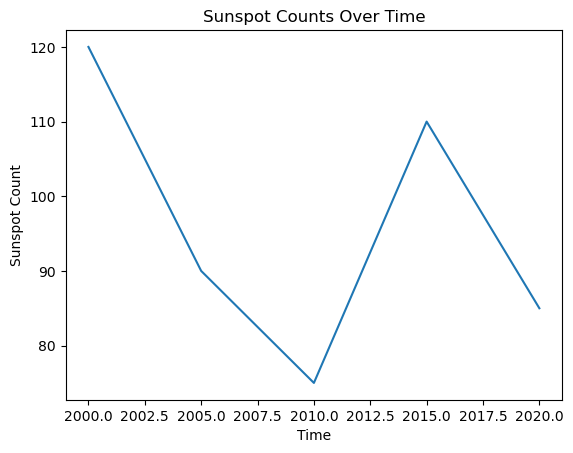

In [30]:
import matplotlib.pyplot as plt

# Here is the most basic example of a plot
years = np.array([2000, 2005, 2010, 2015, 2020])
sunspot_counts = np.array([120, 90, 75, 110, 85])

plt.plot(years, sunspot_counts)
plt.title('Sunspot Counts Over Time')
plt.xlabel('Time')
plt.ylabel('Sunspot Count');

### More advanced plotting

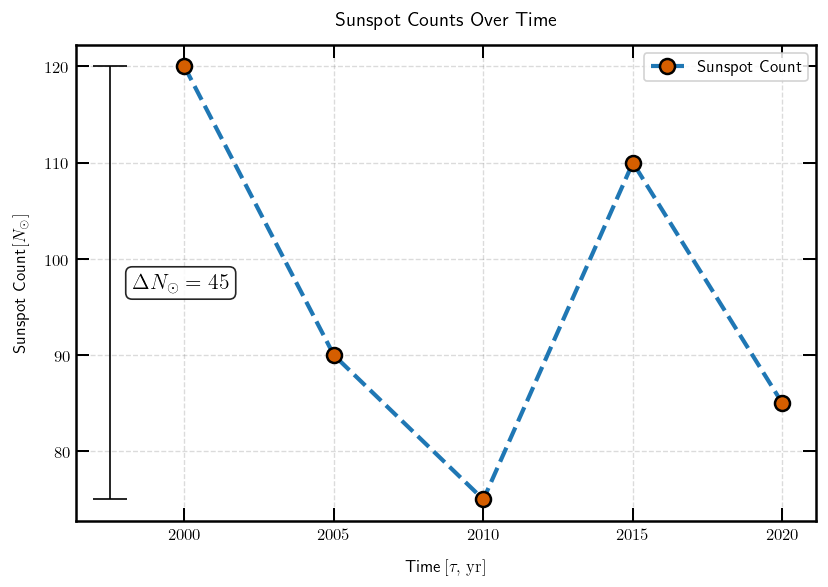

In [31]:
# But we can do better!

# Let's create a custom rc (runtime configuration) dictionary to set the default style of our plot
custom_rc = {
"font.family": "serif",                # Use serif fonts for all text
"font.serif": ["Times New Roman"],     # Specify Times New Roman as the serif font
"mathtext.fontset": "stix",            # Use STIX fonts for math text (matches Times New Roman style)
"axes.linewidth": 1.5,                 # Thicker axis lines for a bolder look
"axes.grid": True,                     # Show grid lines by default
"axes.grid.which": "both",             # Show both major and minor grid lines
"axes.titlepad": 12,                   # Padding (in points) between the title and the plot
"axes.labelpad": 10,                   # Padding (in points) between axis labels and the axes
"xtick.direction": "in",               # Draw x-axis ticks inside the plot
"ytick.direction": "in",               # Draw y-axis ticks inside the plot
"xtick.top": True,                     # Show ticks on the top edge of the plot
"ytick.right": True,                   # Show ticks on the right edge of the plot
"xtick.major.size": 8,                 # Length of major x-ticks (in points)
"ytick.major.size": 8,                 # Length of major y-ticks (in points)
"xtick.minor.size": 4,                 # Length of minor x-ticks
"ytick.minor.size": 4,                 # Length of minor y-ticks
"xtick.major.width": 1.2,              # Thickness of major x-ticks
"ytick.major.width": 1.2,              # Thickness of major y-ticks
"xtick.minor.width": 1.0,              # Thickness of minor x-ticks
"ytick.minor.width": 1.0,              # Thickness of minor y-ticks
"xtick.color": "black",                # Color of x-ticks
"ytick.color": "black",                # Color of y-ticks
"grid.alpha": 0.3,                     # Transparency of grid lines (0=transparent, 1=opaque)
"grid.linestyle": "--",                # Dashed grid lines
"grid.color": "#888888",               # Gray grid lines
"legend.frameon": True,                # Draw a frame (box) around the legend
"legend.framealpha": 0.85,             # Transparency of the legend frame
"legend.loc": "upper right",           # Legend location
"figure.dpi": 120,                     # Dots per inch for figure rendering (higher = sharper)
"figure.facecolor": "white",           # Background color of the figure
"lines.linewidth": 2.5,                # Default line thickness
"lines.linestyle": "--",               # Default line style (dashed)
"lines.color": "#0072B2",              # Default line color (blue)
"lines.marker": "o",                   # Default marker style (circle)
"lines.markersize": 9,                 # Default marker size
"lines.markerfacecolor": "#D55E00",    # Fill color for markers (orange)
"lines.markeredgecolor": "black",      # Edge color for markers
"lines.markeredgewidth": 1.5,          # Edge thickness for markers
"text.usetex": True                    # Set to False if you don't have LaTeX installed, but I highly recommend it!
}

years = np.array([2000, 2005, 2010, 2015, 2020])
sunspot_counts = np.array([120, 90, 75, 110, 85])

with plt.style.context(custom_rc): # Use the custom rc settings
    fig, ax = plt.subplots(figsize=(7, 5))

    ax.plot(years, sunspot_counts, label=r"Sunspot Count")

    # Draw a vertical scale bar with caps to the left of the first point
    bar_x = years[0] - 2.5
    ymin = np.min(sunspot_counts)
    ymax = np.max(sunspot_counts)
    bar_height = ymax - ymin

    ax.errorbar(
        x=bar_x,
        y=(ymax + ymin) / 2,
        yerr=bar_height / 2,
        fmt='none',
        ecolor="black",
        elinewidth=1,
        capsize=10,
        capthick=1,
        zorder=5
    )

    # Add annotation centered to the left of the bar
    ax.annotate(
        r"$\Delta N_\odot = {}$".format(bar_height),
        xy=(bar_x, (ymax + ymin) / 2),
        xytext=(bar_x + 4, (ymax + ymin) / 2),
        va='center', ha='right',
        fontsize=13, color="black",
        bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="black", lw=1, alpha=0.85)
    )
    ax.set_title(r"Sunspot Counts Over Time")
    ax.set_xlabel(r"Time\,$[\tau, \, \rm yr]$")
    ax.set_ylabel(r"Sunspot Count\,$[N_\odot]$")

    ax.legend()

    plt.tight_layout()

### Matplotlib style function and style files

Obviously, it isn't desirable to have a huge block of parameters every time we want to plot something. Luckily, matplotlib has a style function that allows you to choose from several default style options or to read in your own custom style file!

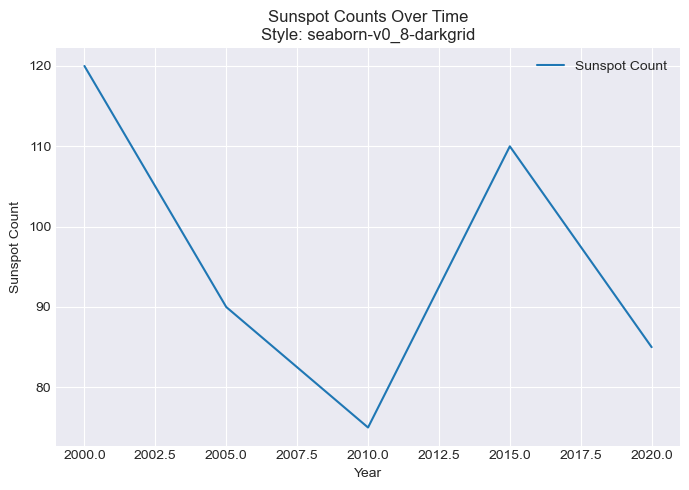

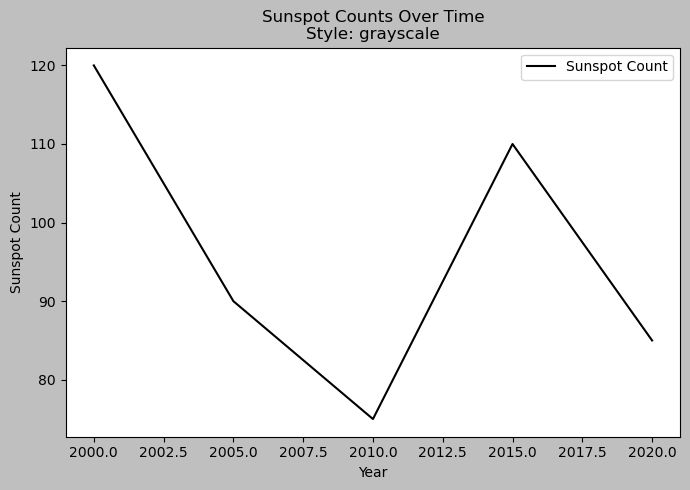

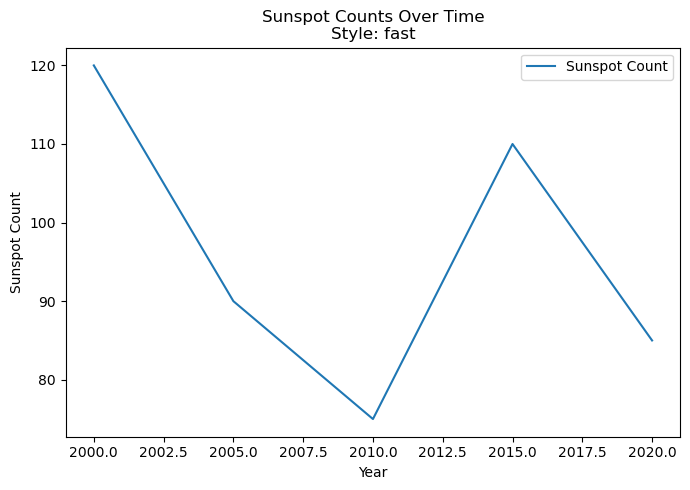

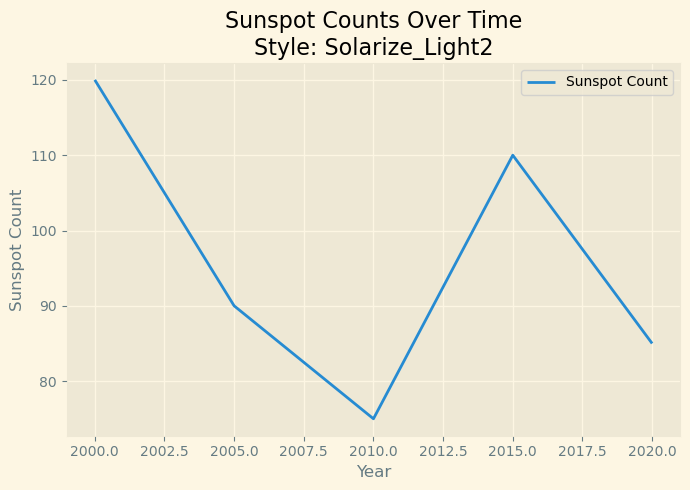

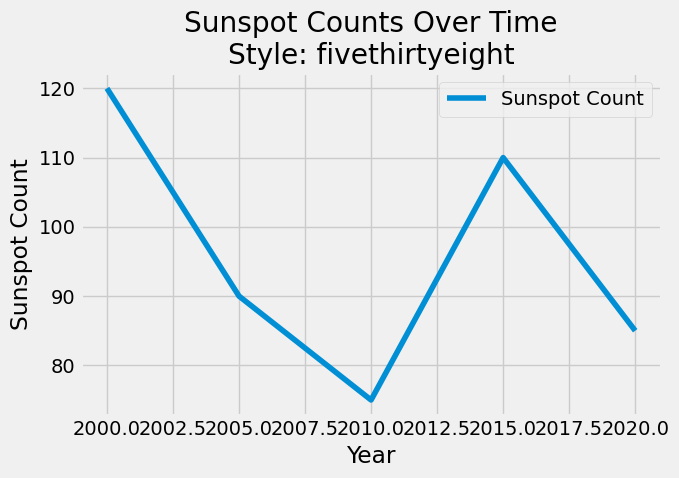

In [32]:
# Let's look at some of the default styles available in matplotlib

years = np.array([2000, 2005, 2010, 2015, 2020])
sunspot_counts = np.array([120, 90, 75, 110, 85])

styles = [
    'seaborn-v0_8-darkgrid',  # Modern, soft colors, grid background
    'grayscale',              # All elements in shades of gray
    'fast',                   # Minimalist, thin lines, no grid
    'Solarize_Light2',        # Solarized color palette, light background
    'fivethirtyeight'         # Bold, thick lines, unique grid and font
]

for style in styles:
    with plt.style.context(style):
        fig, ax = plt.subplots(figsize=(7, 5))
        ax.plot(years, sunspot_counts, label="Sunspot Count")
        ax.set_title(f"Sunspot Counts Over Time\nStyle: {style}")
        ax.set_xlabel("Year")
        ax.set_ylabel("Sunspot Count")
        ax.legend()
        plt.tight_layout()
        plt.show()

Or, we can define our own custom Matplotlib style file by making a text file. The following is the text file that I have made for my own plotting. It is a bit more simple than the custom rc we made, so feel free to mix and match (or change it completely!). This file is saved in the ASTRO_461_Resources drive under the name ```.mplstyle```. Note the dot infront of the file name. This will "hide" the file in your terminal. To view hidden files, run ```ls -a```. You can create your own file by opening your terminal and doing the following:

```Unix
cd
nano .mplsyle_custom
<copy paste what you want into it>
ctrl+X, Y, returm

```python
savefig.bbox : tight
savefig.dpi : 200
figure.dpi : 200
lines.linewidth : 1.5
font.family : serif
font.sans-serif : Times New Roman
font.size : 10
axes.labelsize : 15
xtick.direction : in 
ytick.direction : in
xtick.top : True
ytick.right : True
xtick.major.pad : 5
xtick.minor.pad : 5
ytick.major.pad : 5
ytick.minor.pad : 5
xtick.major.size : 5
ytick.major.size : 5
xtick.labelsize : 12
ytick.labelsize : 12
legend.fontsize : 12
legend.frameon : False
text.usetex : True

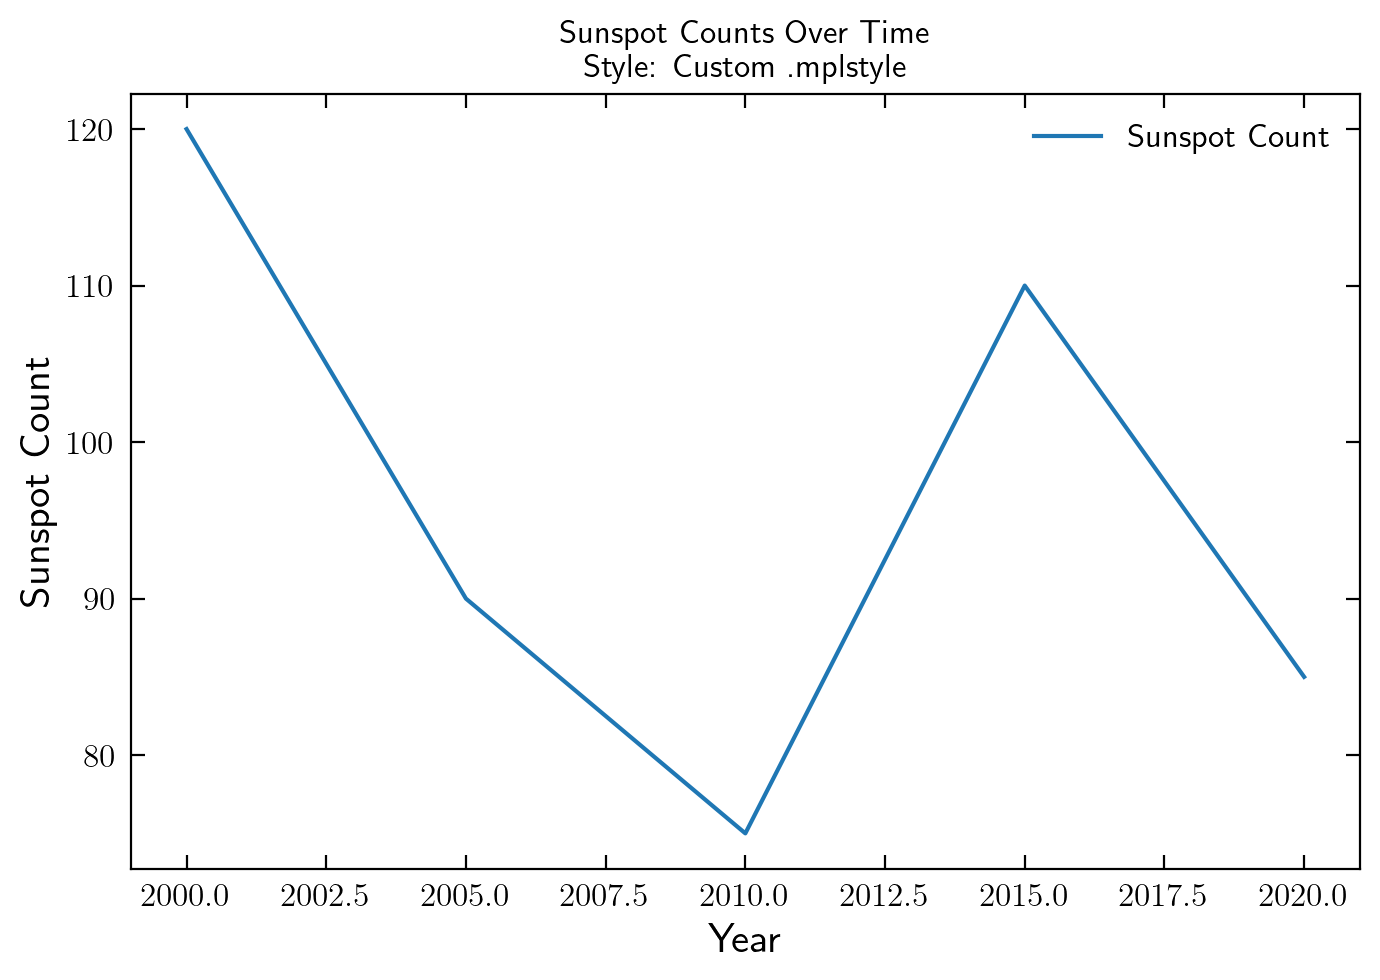

In [33]:
# Let's plot the sunspot data with my custom .mplstyle file!

plt.style.use('./.mplstyle') # Use the custom .mplstyle file. 
# If you make your own with the instrctions above, you can use it here.
# But it is in your home directory, so call it with plt.style.use('~/.mplstyle_custom'). ~ is a shortcut for your home directory.
# NOTE: You only need to call this once, so put it with your import statements at the top of your script. 


fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(years, sunspot_counts, label="Sunspot Count")
ax.set_title(f"Sunspot Counts Over Time\nStyle: Custom .mplstyle")
ax.set_xlabel("Year")
ax.set_ylabel("Sunspot Count")
ax.legend()
plt.tight_layout()


# you can also save your figure to a file (with a file extension of your choice)
plt.savefig('./Sampledata/python_unix_review/figures/sunspot_counts.png')
# plt.savefig('./Sampledata/python_unix_review/figures/sunspot_counts.pdf') # Uncomment to save as a PDF
# plt.savefig('./Sampledata/python_unix_review/figures/sunspot_counts.svg') # Uncomment to save as a SVG
# plt.savefig('./Sampledata/python_unix_review/figures/sunspot_counts.jpg') # Uncomment to save as a JPG

### <span style="color:darkcyan"> Practice Problem 8:</span> Visualizing Stellar Property Distributions
Using the filtered data from problem 7, visualize the distributions of temperatures, magnitudes, and distances of the stars with temperatures above 4000 K. Generate a series of subplots showing histograms for these properties. Annotate each histogram with the mean and standard deviation calculated in problem 7. Use whatever matplotlib style that you want, just don't use the default.

---

## 5. Basic Unix

Here, we'll walk through the process of generating a synthetic astronomical image using a Python script, while incorporating essential Unix commands to manage directories and files. By the end of this exercise, you'll be familiar with basic Unix file operations alongside running Python scripts.

### Setting Up the Environment

First, let's organize our workspace.

1. **List Files and Directories**: Start by listing what's in your current directory.

   ```bash
   ls
   ```

2. **Make a New Directory**: Create a directory for your project and move into it.

   ```bash
   mkdir unix_tutorial
   cd unix_tutorial
   ```

3. **View Current Directory**: Confirm your location in the filesystem.

   ```bash
   pwd
   ```

4. **List All Files**: Check that your new directory is empty, including any hidden files.

   ```bash
   ls -a
   ```

### Creating Your Python Script
0. **Copy the Python code below**

1. **Create a New Python File**: Open a new file in a text editor like `nano`. 

   ```bash
   nano generate_image.py
   ```

2. **Edit the File**: Paste your Python code for generating an image into `generate_image.py`. Save and exit by pressing `CTRL + X`, `Y`, and `return`. Don't forget to change the file path at the end of the script to save the image where you want it to go!

3. **Check the File**: Use `cat` to display the file contents and ensure it's saved correctly.

   ```bash
   cat generate_image.py
   ```

4. **Move Back**: Suppose you decide to organize your script better by moving it to a scripts directory.

   ```bash
   mkdir scripts
   mv generate_image.py scripts/
   cd scripts
   ```

5. **Confirm the Move**: List files to verify the script is in the correct directory.

   ```bash
   ls
   ```

### Running the Python Script

1. **Execute the Script**: Run the Python script to generate the image.

   ```bash
   python generate_image.py
   ```

2. **Output Check**: If your script includes command lines for saving images, check the output with `ls`.

   ```bash
   ls
   ```

3. **Redirect and Append Output**: Suppose you have print statements you want to review later. Redirect the output to a file.

   ```bash
   python generate_image.py > output.txt
   ```

   Run again with `>>` to append any additional output.

   ```bash
   python generate_image.py >> output.txt
   ```

### Managing Files and Viewing Output

1. **Check Output**: Use `more` to view the output file one page at a time.

   ```bash
   more output.txt
   ```

2. **Inspect Specific Lines**: View the first or last few lines of the output.

   ```bash
   head output.txt
   tail output.txt
   ```

3. **Search for Keywords**: If you're debugging, you could search for error messages or specific keywords.

   ```bash
   grep 'ERROR' output.txt
   ```
   ```bash
   grep 'SUCCESS' output.txt
   ```

4. **Count Entries**: Verify how many lines of output were generated.

   ```bash
   wc output.txt
   ```

### Cleaning Up

1. **Remove Files**: Clean up any files you no longer need.

   ```bash
   rm output.txt
   ```

2. **Directory Navigation**: Move back to the main project directory.

   ```bash
   cd ..
   ```

3. **Remove Directory**: If needed, remove the scripts directory.

   ```bash
   rmdir scripts
   ```

### Exploring Commands and Help

1. **Check Command Usage**: Find brief descriptions and detailed manuals if needed.

   ```bash
   ls --help
   whatis ls
   man ls
   ```

2. **Search Commands**: Use `apropos` to find commands related to keywords.

   ```bash
   apropos directory
   ```